# Robustness Evaluation Under Adversarial Attack
This notebook evaluates how the trained baseline defenders perform when subjected to five static evasion attacks (amount_scaling, time_shift, category_mimicry, velocity_spacing, combined)

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
import sys
sys.path.append('..')

print("Libraries imported successfully")

Libraries imported successfully


# Load data and defender models

In [2]:
clean_df = pd.read_csv('../data/featured_transactions_v2.csv')
clean_df['Timestamp'] = pd.to_datetime(clean_df['Timestamp'])
cutoff = clean_df['Timestamp'].quantile(0.8)
test = clean_df[clean_df['Timestamp'] > cutoff]


attacked_datasets = {
    'amount_scaling': pd.read_csv('../data/attacked_transactions_amount_scaling.csv'),
    'category_mimicry': pd.read_csv('../data/attacked_transactions_category_mimicry.csv'),
    'time_shift': pd.read_csv('../data/attacked_transactions_time_shift.csv'),
    'velocity_spacing': pd.read_csv('../data/attacked_transactions_velocity_spacing.csv'),
    'combined': pd.read_csv('../data/attacked_transactions_combined.csv')
}

model_names = ['lr_balanced', 'rf_balanced', 'xgb_balanced']
models = {name: joblib.load(f'../results/models/{name}.pkl') for name in model_names}

print(f"Clean test data shape: {test.shape}")
print(f"Models loaded: {list(models.keys())}")

Clean test data shape: (50672, 13)
Models loaded: ['lr_balanced', 'rf_balanced', 'xgb_balanced']


## Robustness Evaluation
For each (model, attacker) pair:
1. Compute the F1-optimal threshold from clean test data
2. Load the attacked dataset for that attacker
3. Evaluate the model on the attacked data using the fixed clean threshold
4. Record recall drop and AUPRC degradation

In [3]:
feature_cols = ['amount_zscore', 'transactions_last_1h', 'amount_sum_last_24h', 'log_time_since_last_txn',  'is_new_category', 'is_foreign', 
               'hour_of_day', 'is_night']

scaler = joblib.load('../results/models/scaler.pkl')
X_clean = pd.DataFrame(scaler.transform(test[feature_cols]),columns=feature_cols)
y_clean = test['is_fraud']

attack_names = [
    'amount_scaling',
    'time_shift',
    'category_mimicry',
    'velocity_spacing',
    'combined'
]

def get_clean_threshold(model, X_clean, y_clean):
    """Get optimal threshold from clean data once per model."""
    y_proba = model.predict_proba(X_clean)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_clean, y_proba)
    f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = f1s[:-1].argmax()
    return thresholds[best_idx]

def evaluate_robustness(model, X_attacked, y_attacked, fixed_threshold):
    """Evaluate on attacked data using the clean-optimal threshold."""
    y_proba = model.predict_proba(X_attacked)[:, 1]
    y_pred = (y_proba >= fixed_threshold).astype(int)
    return {
        'recall': recall_score(y_attacked, y_pred, zero_division=0),
        'precision': precision_score(y_attacked, y_pred, zero_division=0),
        'f1': f1_score(y_attacked, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_attacked, y_proba),
        'avg_precision': average_precision_score(y_attacked, y_proba)
    }

results = []

for model_name, model in models.items():
    # Step 1: get fixed threshold from clean data once per model
    fixed_threshold = get_clean_threshold(model, X_clean, y_clean)
    clean_metrics = evaluate_robustness(model, X_clean, y_clean, fixed_threshold)
    print(f"{model_name} | clean threshold: {fixed_threshold:.3f} | clean recall: {clean_metrics['recall']:.3f}")

    for attack_name in attack_names:
        # Step 2: load attacked data
        attacked_df = pd.read_csv(f'../data/attacked_transactions_{attack_name}.csv')
        X_attacked = pd.DataFrame(
            scaler.transform(attacked_df[feature_cols]),
            columns=feature_cols
        )
        y_attacked = attacked_df['is_fraud']

        # Step 3: evaluate using fixed threshold
        attacked_metrics = evaluate_robustness(model, X_attacked, y_attacked, fixed_threshold)

        results.append({
            'model': model_name,
            'attacker': attack_name,
            'clean_recall': clean_metrics['recall'],
            'attacked_recall': attacked_metrics['recall'],
            'recall_drop': clean_metrics['recall'] - attacked_metrics['recall'],
            'clean_f1': clean_metrics['f1'],
            'attacked_f1': attacked_metrics['f1'],
            'roc_auc': attacked_metrics['roc_auc'],
            'clean_avg_precision': clean_metrics['avg_precision'],
            'attacked_avg_precision': attacked_metrics['avg_precision'],
        })

results_df = pd.DataFrame(results)
results_df.to_csv('../results/robustness_results.csv', index=False)

print("\nRobustness results saved!")
print(results_df)

lr_balanced | clean threshold: 0.801 | clean recall: 0.643
rf_balanced | clean threshold: 0.687 | clean recall: 0.820
xgb_balanced | clean threshold: 0.702 | clean recall: 0.805

Robustness results saved!
           model          attacker  clean_recall  attacked_recall  \
0    lr_balanced    amount_scaling      0.642782         0.735511   
1    lr_balanced        time_shift      0.642782         0.646997   
2    lr_balanced  category_mimicry      0.642782         0.589041   
3    lr_balanced  velocity_spacing      0.642782         0.786091   
4    lr_balanced          combined      0.642782         0.394099   
5    rf_balanced    amount_scaling      0.819810         0.754478   
6    rf_balanced        time_shift      0.819810         0.501581   
7    rf_balanced  category_mimicry      0.819810         0.706006   
8    rf_balanced  velocity_spacing      0.819810         0.652266   
9    rf_balanced          combined      0.819810         0.159115   
10  xgb_balanced    amount_scaling  

## Recall Drop Heatmap
Visualise the recall degradation matrix across all model-attacker combinations. Darker colours indicate greater evasion success.

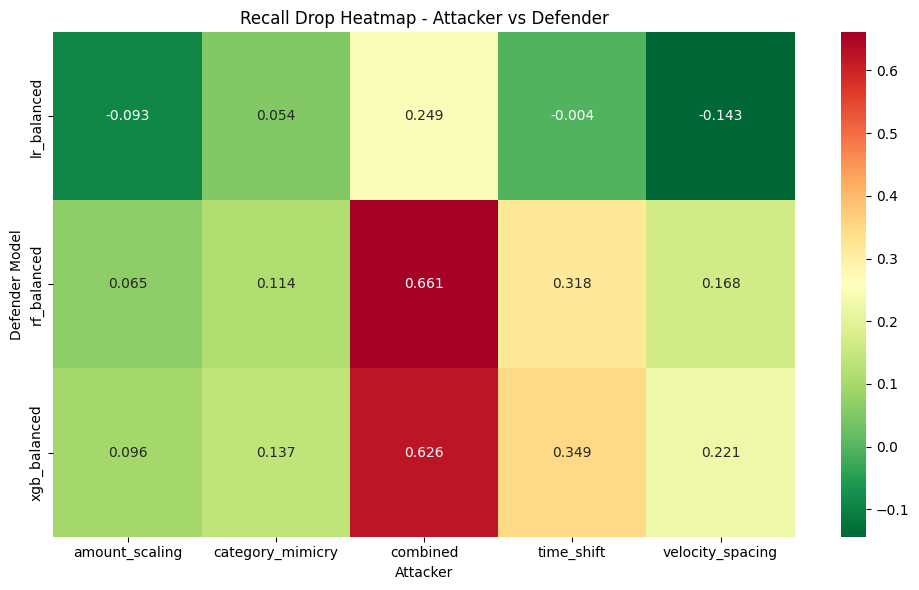

In [4]:
heatmap_data = results_df.pivot(index='model', columns='attacker', values='recall_drop')
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn_r')
plt.title('Recall Drop Heatmap - Attacker vs Defender')
plt.ylabel('Defender Model')
plt.xlabel('Attacker')
plt.tight_layout()
plt.savefig('../results/recall_drop_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Clean vs Attacked Recall by Attacker
For each attacker, compare clean and attacked recall across all three models side by side.

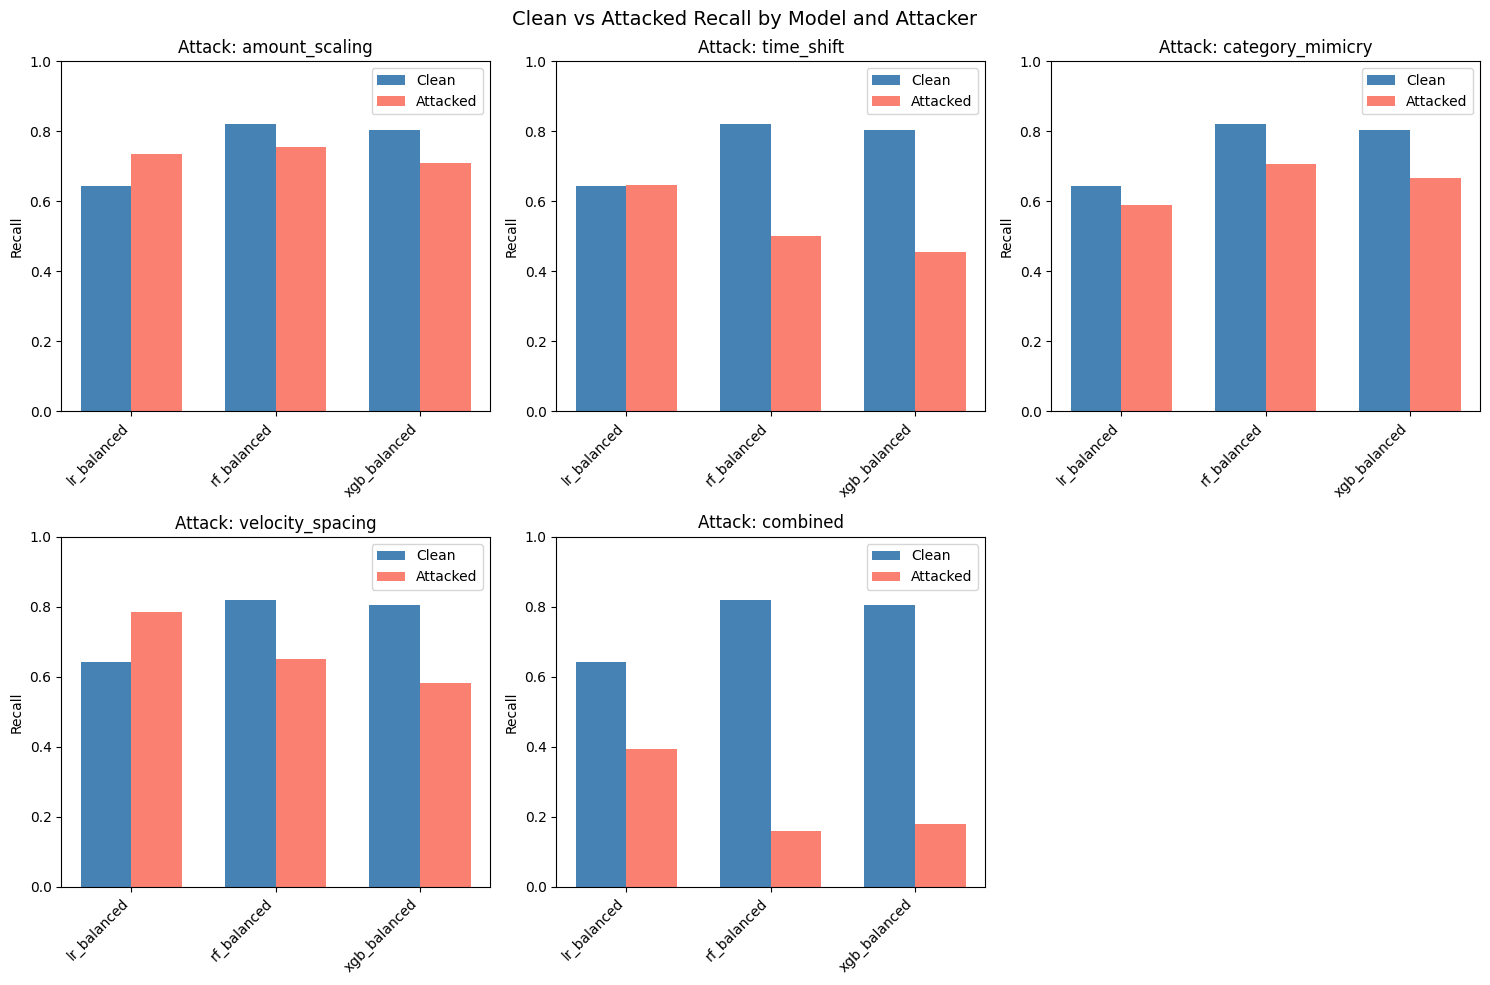

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

attackers = results_df['attacker'].unique()

for i, attacker in enumerate(attackers):
    ax = axes[i]
    attacker_data = results_df[results_df['attacker'] == attacker]
    
    x = np.arange(len(attacker_data))
    width = 0.35
    
    # plot clean recall bars
    ax.bar(x - width/2, attacker_data['clean_recall'], width, label='Clean', color='steelblue')
    
    # plot attacked recall bars — have a go at this line
    ax.bar(x + width/2, attacker_data['attacked_recall'], width, label='Attacked', color='salmon')
    
    ax.set_title(f'Attack: {attacker}')
    ax.set_xticks(x)
    ax.set_xticklabels(attacker_data['model'], rotation=45, ha='right')
    ax.set_ylabel('Recall')
    ax.set_ylim(0, 1)
    ax.legend()

axes[5].set_visible(False)

plt.suptitle('Clean vs Attacked Recall by Model and Attacker', fontsize=14)
plt.tight_layout()
plt.show()

## Confusion Matrices: Clean vs Combined Attack
The combined attack chains all four evasion strategies simultaneously. 

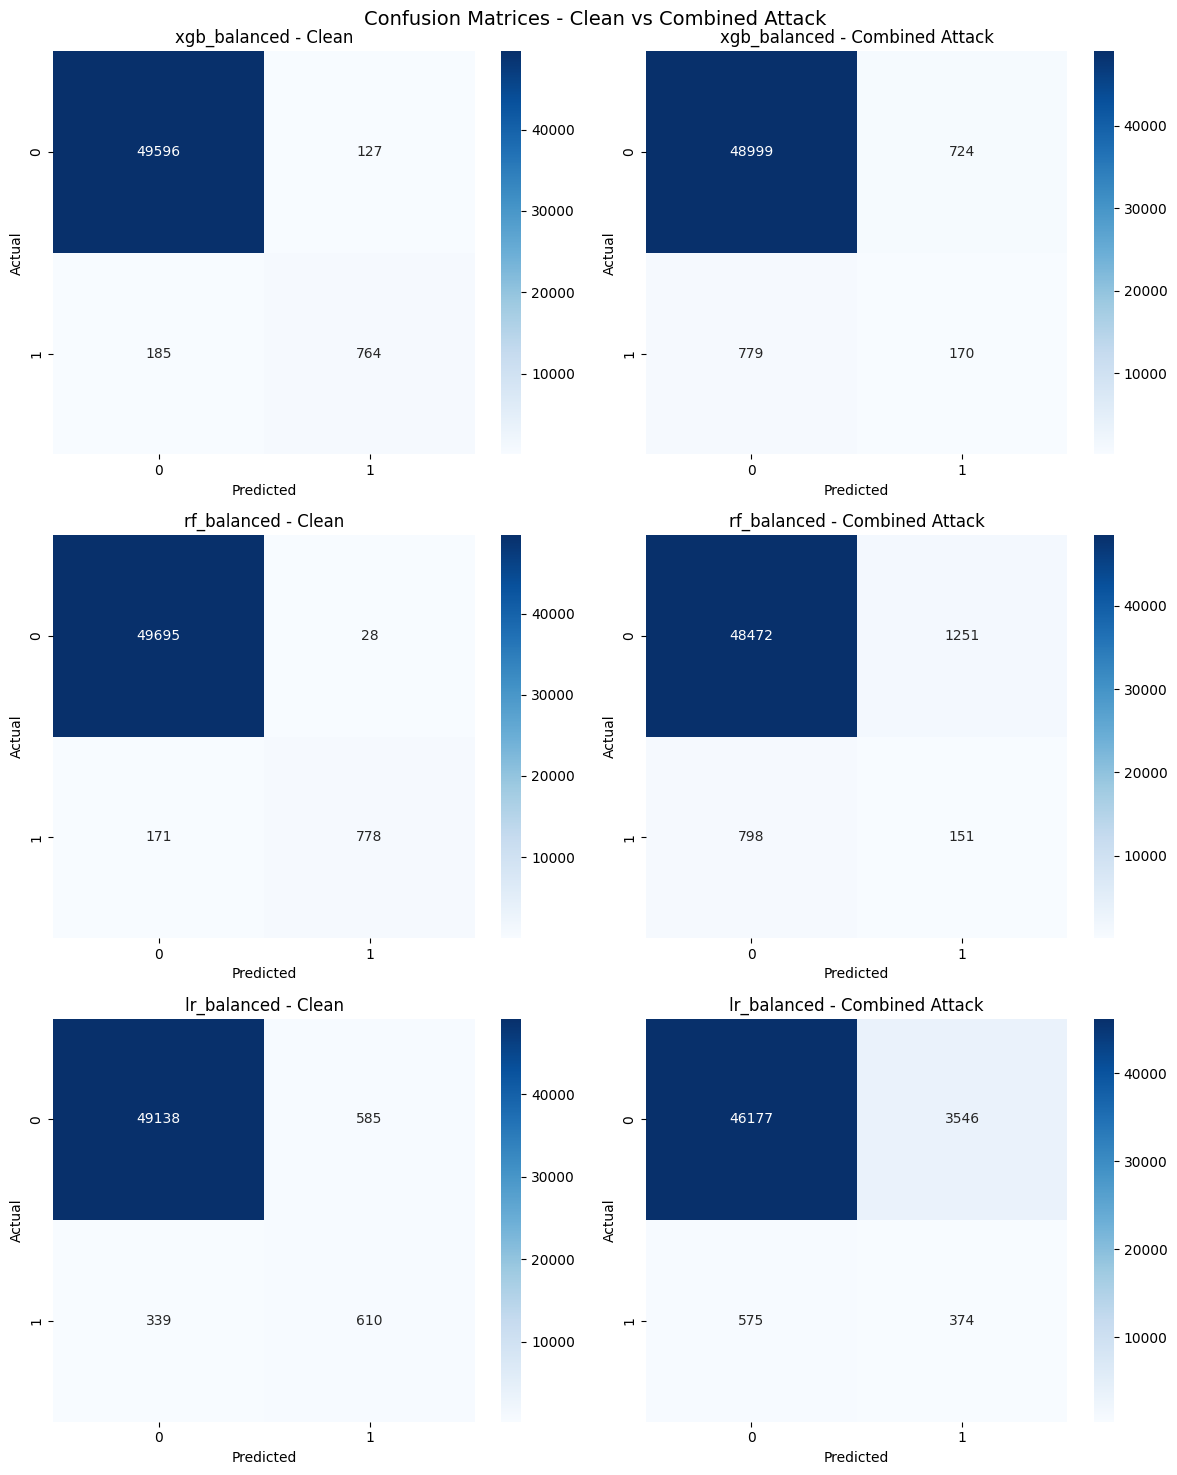

In [6]:
combined_df = attacked_datasets['combined']
X_attacked_combined = pd.DataFrame(scaler.transform(combined_df[feature_cols]), columns=feature_cols)
y_attacked_combined = combined_df['is_fraud']

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

models_to_plot = ['xgb_balanced', 'rf_balanced', 'lr_balanced']

for i, model_name in enumerate(models_to_plot):
    model = models[model_name]

    # get fixed threshold for this model
    fixed_threshold = get_clean_threshold(model, X_clean, y_clean)
    
    # clean predictions
    y_pred_clean = (model.predict_proba(X_clean)[:, 1] >= fixed_threshold).astype(int)
    
    # attacked predictions
    y_pred_attacked = (model.predict_proba(X_attacked_combined)[:, 1] >= fixed_threshold).astype(int)
    
    # plot clean
    cm_clean = confusion_matrix(y_clean, y_pred_clean)
    sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Blues', ax=axes[i][0])
    axes[i][0].set_title(f'{model_name} - Clean')
    axes[i][0].set_ylabel('Actual')
    axes[i][0].set_xlabel('Predicted')
    
    # plot attacked
    cm_attacked = confusion_matrix(y_attacked_combined, y_pred_attacked)
    sns.heatmap(cm_attacked, annot=True, fmt='d', cmap='Blues', ax=axes[i][1])
    axes[i][1].set_title(f'{model_name} - Combined Attack')
    axes[i][1].set_ylabel('Actual')
    axes[i][1].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - Clean vs Combined Attack', fontsize=14)
plt.tight_layout()
plt.savefig('../results/confusion_matrices_clean_vs_combined.png', dpi=300, bbox_inches='tight')
plt.show()

These confusion matrices show how true positives (detected fraud) collapse under the most severe attack.